<a href="https://colab.research.google.com/github/tiran543/Statistical-Learning-e23094/blob/main/Copy_of_Kalman_filter_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q. Analytical Derivation

Consider the filter model
\begin{align*}
x^{-}_k &= A_{k-1}\,x^{+}_{k-1} + G_{k-1}\,w_{k-1}, \\
y^{-}_k &= H_k\,x^{-}_k + z_k,
\end{align*}
where
$$x^{+}_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1}),$$

Answer the followings:

1. Show that
$$x_k^- \sim \mathscr{N}(m_k^-, P_k^-),$$
where
$$m_k^- = A_{k-1}m_{k-1},$$
and
$$
P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T.
$$

2. Show that
$$y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m).$$

3. Show that
$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right).$$

4. Show that
$$x^{+}_k\triangleq (x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) \sim \mathscr{N}(m_k, P_k),$$
where the updated mean $m_k$ and updated covariance $P_k$ are given by:
\begin{align*}
K_k &\triangleq P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}, \\
m_k &= m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-), \\
P_k &= (I - K_k H_k) P_k^-.
\end{align*}

5. Find
$\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}]$  and
$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k})$.

1.$$\mathbb{E}[x_k^-] = A_{k-1} \mathbb{E}[x_{k-1}^+] + G_{k-1} \mathbb{E}[w_{k-1}] = A_{k-1} m_{k-1}$$$$\text{Var}(x_k^-) = A_{k-1} \text{Var}(x_{k-1}^+) A_{k-1}^T + G_{k-1} \text{Var}(w_{k-1}) G_{k-1}^T = A_{k-1} P_{k-1} A_{k-1}^T + G_{k-1} \Sigma_p G_{k-1}^T$$2.$$\mathbb{E}[y_k^-] = H_k \mathbb{E}[x_k^-] + \mathbb{E}[z_k] = H_k m_k^-$$$$\text{Var}(y_k^-) = H_k \text{Var}(x_k^-) H_k^T + \text{Var}(z_k) = H_k P_k^- H_k^T + \Sigma_m$$3.$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}[(x_k^- - m_k^-) (H_k (x_k^- - m_k^-) + z_k)^T]$$$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}[(x_k^- - m_k^-) (x_k^- - m_k^-)^T] H_k^T + \mathbb{E}[(x_k^- - m_k^-) z_k^T]$$$$\text{Cov}(x_k^-, y_k^-) = P_k^- H_k^T + 0 = P_k^- H_k^T$$$$\text{Cov}(y_k^-, x_k^-) = (P_k^- H_k^T)^T = H_k P_k^-$$4.$$K_k = \text{Cov}_{xy} (\text{Var}_{yy})^{-1} = P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}$$$$m_k = \text{Mean}_x + K_k (y_k^{obs} - \text{Mean}_y) = m_k^- + K_k (y_k^{obs} - H_k m_k^-)$$$$P_k = \text{Var}_x - K_k \text{Cov}_{yx} = P_k^- - K_k (H_k P_k^-) = (I - K_k H_k) P_k^-$$5.$$\mathbb{E}[x_k^- \mid y_k^- = y_k^{obs}] = m_k^- + K_k (y_k^{obs} - H_k m_k^-)$$$$\text{Var}(x_k^- \mid y_k^- = y_k^{obs}) = (I - K_k H_k) P_k^-$$

# Q. 1-D Example

Consider the scalar linear-Gaussian filter model
\begin{aligned}
x^-_k &= a\,x^+_{k-1} + w_{k-1},\qquad w_{k-1}\sim\mathscr N(0,q),\\
y^-_k &= h\,x^-_k + z_k,\qquad\;\;\;\; z_k\sim\mathscr N(0,r),
\end{aligned}
with prior $x_0\sim \mathscr{N}(m_0,P_0)$. Define $Y_{k}=\{y^{\mathrm{obs}}_1,\dots,y^{\mathrm{obs}}_{k}\}$.

Answer the following:

1. Show that
\begin{aligned}
m_k^- &= a\,m_{k-1},\\
P_k^- &= a^2 P_{k-1} + q.
\end{aligned}

2. Show that
\begin{aligned}
m_k &= m_k^- + K_k\,v_k
= m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr),\\
P_k &= (1 - K_k h)\,P_k^-
= \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^- .
\end{aligned}

3. Show that the predictive measurement distribution (before seeing $y_k$):
\begin{align*}
p(y^-_k | Y_{k-1})=\mathscr N\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr).
\end{align*}

4. Show that the posterior-predictive measurement distribution (after filtering on $y_k$):
\begin{align*}
p(y^-_k\mid Y_k)=\mathscr N\bigl(h\,m_k,\; h^2 P_k + r\bigr).
\end{align*}

5. For suitable numerical values for $a,q,h,r$ animate the above to prior distribution and the posterior distribution.

1.$$m_k^- = \mathbb{E}[a x_{k-1}^+ + w_{k-1}] = a \mathbb{E}[x_{k-1}^+] + \mathbb{E}[w_{k-1}] = a m_{k-1}$$$$P_k^- = \text{Var}(a x_{k-1}^+ + w_{k-1}) = a^2 \text{Var}(x_{k-1}^+) + \text{Var}(w_{k-1}) = a^2 P_{k-1} + q$$2.$$v_k = y_k^{obs} - h m_k^-$$$$S_k = \text{Var}(y_k^-) = h^2 P_k^- + r$$$$K_k = \frac{\text{Cov}(x_k^-, y_k^-)}{S_k} = \frac{P_k^- h}{S_k}$$$$m_k = m_k^- + K_k v_k = m_k^- + \frac{P_k^- h}{S_k}(y_k^{obs} - h m_k^-)$$$$P_k = P_k^- - K_k \text{Cov}(y_k^-, x_k^-) = P_k^- - K_k (h P_k^-) = (1 - K_k h) P_k^- = \left( 1 - \frac{P_k^- h^2}{S_k} \right) P_k^-$$3.$$\mathbb{E}[y_k^- \mid Y_{k-1}] = h \mathbb{E}[x_k^- \mid Y_{k-1}] + \mathbb{E}[z_k] = h m_k^- + 0 = h m_k^-$$$$\text{Var}(y_k^- \mid Y_{k-1}) = h^2 \text{Var}(x_k^- \mid Y_{k-1}) + \text{Var}(z_k) = h^2 P_k^- + r$$$$p(y_k^- \mid Y_{k-1}) = \mathcal{N}(h m_k^-, h^2 P_k^- + r)$$4.$$\mathbb{E}[y_k^- \mid Y_k] = h \mathbb{E}[x_k \mid Y_k] + \mathbb{E}[z_k] = h m_k + 0 = h m_k$$$$\text{Var}(y_k^- \mid Y_k) = h^2 \text{Var}(x_k \mid Y_k) + \text{Var}(z_k) = h^2 P_k + r$$$$p(y_k^- \mid Y_k) = \mathcal{N}(h m_k, h^2 P_k + r)$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.stats import norm
from IPython.display import HTML

# 1. Define suitable numerical values
a = 1.0  # State transition
h = 1.0  # Observation scalar
q = 0.5  # Process noise variance
r = 1.0  # Measurement noise variance

n_steps = 20
np.random.seed(42)

# Generate synthetic true states and noisy observations
x_true = np.zeros(n_steps)
y_obs = np.zeros(n_steps)
x_true[0] = 0.0

for k in range(1, n_steps):
    x_true[k] = a * x_true[k-1] + np.random.normal(0, np.sqrt(q))
    y_obs[k] = h * x_true[k] + np.random.normal(0, np.sqrt(r))

# Initial Prior
m = 0.0
P = 2.0

m_minus_list, P_minus_list = [], []
m_plus_list, P_plus_list = [], []

# Run 1-D Kalman Filter
for k in range(n_steps):
    # Predict (Prior)
    m_minus = a * m
    P_minus = a**2 * P + q
    m_minus_list.append(m_minus)
    P_minus_list.append(P_minus)

    # Update (Posterior)
    S = h**2 * P_minus + r
    K = (P_minus * h) / S
    m = m_minus + K * (y_obs[k] - h * m_minus)
    P = (1 - K * h) * P_minus

    m_plus_list.append(m)
    P_plus_list.append(P)

# 2. Animate the Distributions
fig, ax = plt.subplots(figsize=(8, 5))
x_axis = np.linspace(-10, 10, 500)

line_prior, = ax.plot([], [], label='Prior (Predictive) $p(x_k^-)$', color='blue', linestyle='--')
line_posterior, = ax.plot([], [], label='Posterior (Updated) $p(x_k^+)$', color='red')
point_obs, = ax.plot([], [], 'ko', markersize=8, label='Observation $y_k^{obs}$')

ax.legend(loc='upper right')
ax.set_ylim(0, 0.8)
ax.set_xlim(-10, 10)
ax.set_xlabel('State Space')
ax.set_ylabel('Probability Density')

def init():
    line_prior.set_data([], [])
    line_posterior.set_data([], [])
    point_obs.set_data([], [])
    return line_prior, line_posterior, point_obs

def animate(i):
    # Prior PDF
    pdf_prior = norm.pdf(x_axis, m_minus_list[i], np.sqrt(P_minus_list[i]))
    line_prior.set_data(x_axis, pdf_prior)

    # Posterior PDF
    pdf_posterior = norm.pdf(x_axis, m_plus_list[i], np.sqrt(P_plus_list[i]))
    line_posterior.set_data(x_axis, pdf_posterior)

    # Observation Point
    point_obs.set_data([y_obs[i]], [0.02]) # Plotted slightly above axis to be visible

    ax.set_title(f'1-D Kalman Filter: Step {i}')
    return line_prior, line_posterior, point_obs

anim = FuncAnimation(fig, animate, init_func=init, frames=n_steps, interval=600, blit=True)
plt.close() # Prevents static plot from rendering alongside animation

# Display in Colab
HTML(anim.to_jshtml())

# Q. 2D-Position Estimation

## Part A

Consider a two-dimensional constant-velocity dynamical system. The hidden state at time step $k$ is

$$
x_k =
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix},
$$

where $(p_x(k),p_y(k))$ denote the position components and $(v_x(k),v_y(k))$ denote the velocity components.

The measurement consists only of the two position components:

$$
y_k =
\begin{bmatrix}
p_x^{\mathrm{meas}}(k)\\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}.
$$

The linear Gaussian state-space filter model is

$$
x^-_k = A x^+_{k-1} + G w_{k-1},
$$

$$
y^-_k = Hx^+_k + z_k,
$$

where

$$
w_{k-1} \sim \mathscr{N}(0,\Sigma_p),
\qquad
z_k \sim \mathscr{N}(0,\Sigma_m).
$$

The process noise sequence $w_k$, measurement noise sequence $z_k$, and the initial state are assumed mutually independent.

Show that:

$$
A =
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix},
$$



$$
H =
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix},
$$

and

$$
G =
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}.
$$

## Part B

Develop a python based method to filter a sequence of noisy GPS obtained position meaurements.

$$p_x(k) = p_x(k-1) + v_x(k-1)\Delta t$$
$$p_y(k) = p_y(k-1) + v_y(k-1)\Delta t$$
$$v_x(k) = v_x(k-1)$$
$$v_y(k) = v_y(k-1)$$
$$A = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}$$

$$p_x^{\text{meas}}(k) = p_x(k)$$
$$p_y^{\text{meas}}(k) = p_y(k)$$
$$H = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix}$$

$$p_x(k) = p_x(k-1) + v_x(k-1)\Delta t + \frac{1}{2} w_x \Delta t^2$$
$$p_y(k) = p_y(k-1) + v_y(k-1)\Delta t + \frac{1}{2} w_y \Delta t^2$$
$$v_x(k) = v_x(k-1) + w_x \Delta t$$
$$v_y(k) = v_y(k-1) + w_y \Delta t$$
$$G = \begin{bmatrix} \frac{1}{2}\Delta t^2 & 0 \\ 0 & \frac{1}{2}\Delta t^2 \\ \Delta t & 0 \\ 0 & \Delta t \end{bmatrix}$$

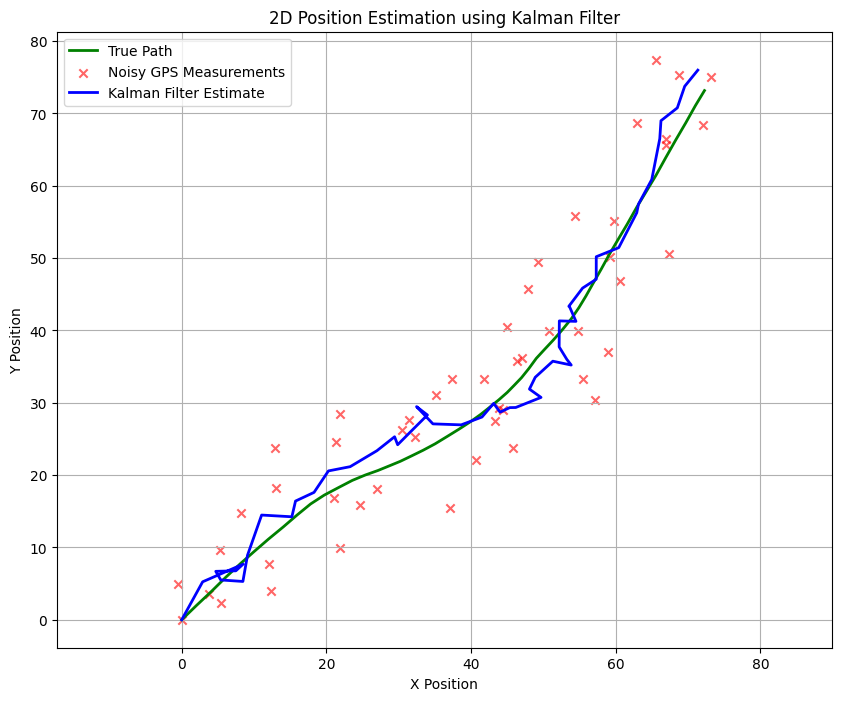

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Initialize System Parameters
dt = 1.0  # Time step
num_steps = 50

# Define matrices (as derived in Part A)
A = np.array([[1, 0, dt, 0],
              [0, 1, 0, dt],
              [0, 0, 1, 0],
              [0, 0, 0, 1]])

H = np.array([[1, 0, 0, 0],
              [0, 1, 0, 0]])

G = np.array([[0.5 * dt**2, 0],
              [0, 0.5 * dt**2],
              [dt, 0],
              [0, dt]])

# Noise parameters
sigma_accel = 0.2  # Process noise
sigma_gps = 5.0    # Measurement noise

Sigma_p = (sigma_accel**2) * np.eye(2)
Sigma_m = (sigma_gps**2) * np.eye(2)

# 2. Generate Synthetic Data
np.random.seed(42)
x_true = np.zeros((4, num_steps))
y_meas = np.zeros((2, num_steps))

# Initial conditions [px, py, vx, vy]
x_true[:, 0] = [0, 0, 2, 2]

for k in range(1, num_steps):
    w = np.random.multivariate_normal([0, 0], Sigma_p)
    x_true[:, k] = A @ x_true[:, k-1] + G @ w
    z = np.random.multivariate_normal([0, 0], Sigma_m)
    y_meas[:, k] = H @ x_true[:, k] + z

# 3. 2D Kalman Filter
m = np.array([0.0, 0.0, 0.0, 0.0]) # Initial state estimate
P = np.eye(4) * 10                 # Initial covariance estimate

m_filtered = np.zeros((4, num_steps))

for k in range(num_steps):
    # Predict (Prior)
    m_minus = A @ m
    P_minus = A @ P @ A.T + G @ Sigma_p @ G.T

    # Update (Posterior)
    S = H @ P_minus @ H.T + Sigma_m
    K = P_minus @ H.T @ np.linalg.inv(S)

    m = m_minus + K @ (y_meas[:, k] - H @ m_minus)
    P = (np.eye(4) - K @ H) @ P_minus

    m_filtered[:, k] = m

# 4. Plotting the results
plt.figure(figsize=(10, 8))
plt.plot(x_true[0, :], x_true[1, :], label='True Path', color='green', linewidth=2)
plt.scatter(y_meas[0, :], y_meas[1, :], label='Noisy GPS Measurements', color='red', marker='x', alpha=0.6)
plt.plot(m_filtered[0, :], m_filtered[1, :], label='Kalman Filter Estimate', color='blue', linewidth=2)

plt.title('2D Position Estimation using Kalman Filter')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()